<a href="https://colab.research.google.com/github/KanujanS/Suitable-Technology-Stacks/blob/main/research_preprocessing.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
# ══════════════════════════════════════════════════════════════
# CELL 1 ─ Imports
# ══════════════════════════════════════════════════════════════
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
import joblib, os, warnings

from sklearn.preprocessing import LabelEncoder
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.model_selection import train_test_split

warnings.filterwarnings("ignore")
print("✓ All libraries imported")

✓ All libraries imported


In [2]:
# ══════════════════════════════════════════════════════════════
# CELL 2 ─ Upload & load
# ══════════════════════════════════════════════════════════════
from google.colab import files

print("Upload your file: github_projects_cleaned.xlsx")
uploaded = files.upload()
filename = list(uploaded.keys())[0]

df_raw = pd.read_excel(filename)
print(f"\n✓ Loaded {len(df_raw):,} rows × {len(df_raw.columns)} columns")
print("Columns:", list(df_raw.columns))
df_raw.head(3)

Upload your file: github_projects_cleaned.xlsx


Saving github_projects_cleaned.xlsx to github_projects_cleaned.xlsx

✓ Loaded 4,437 rows × 19 columns
Columns: ['Project_ID', 'Project_Name', 'Domain', 'Project_Description', 'Functional_Requirements', 'Non_Functional_Requirements', 'Project_Size', 'Team_Size', 'Budget_Level', 'Duration_Months', 'Deployment', 'Frontend_Tech', 'Backend_Tech', 'Database', 'Source', 'GitHub_URL', 'Stars', 'Forks', 'Primary_Language']


,Project_ID,Project_Name,Domain,Project_Description,Functional_Requirements,Non_Functional_Requirements,Project_Size,Team_Size,Budget_Level,Duration_Months,Deployment,Frontend_Tech,Backend_Tech,Database,Source,GitHub_URL,Stars,Forks,Primary_Language
0,GH0001,Bitcoin,Finance,Bitcoin Core integration/staging tree,"bitcoin, c-plus-plus, cryptocurrency, cryptogr...","PCI-DSS compliance, regulatory compliance, enc...",Large,21,High,14,On-premise,Angular,Go,PostgreSQL,GitHub,https://github.com/bitcoin/bitcoin,10000,5000,C++
1,GH0002,Core,IoT & Smart Systems,:housewithgarden: Open source home automation ...,"asyncio, hacktoberfest, home-automation, inter...","reliability, real-time processing, security",Large,27,High,22,On-premise,React,Django,MongoDB,GitHub,https://github.com/home-assistant/core,10000,5000,Python
2,GH0003,Memos,Social Media,"Open-source, self-hosted note-taking tool buil...","docker, foss, go, markdown, memo, microblog","real-time performance, media optimization, low...",Large,30,High,14,Cloud,React,Go,PostgreSQL,GitHub,https://github.com/usememos/memos,10000,4307,Go


In [3]:
# ══════════════════════════════════════════════════════════════
# CELL 3 ─ Keep only the 11 ML-relevant columns
# ══════════════════════════════════════════════════════════════
# Columns like Project_ID, GitHub_URL, Stars are metadata —
# they have no predictive value and must be dropped before
# building any feature matrix.

ML_COLS = [
    "Domain",                       # feature  → one-hot encoded
    "Functional_Requirements",      # feature  → TF-IDF text
    "Non_Functional_Requirements",  # feature  → TF-IDF text
    "Project_Size",                 # feature  → ordinal (Small=0, Medium=1, Large=2)
    "Team_Size",                    # feature  → numeric, kept as-is
    "Budget_Level",                 # feature  → ordinal (Low=0, Medium=1, High=2)
    "Duration_Months",              # feature  → numeric, kept as-is
    "Deployment",                   # feature  → binary (On-premise=0, Cloud=1)
    "Frontend_Tech",                # TARGET 1 → label encoded
    "Backend_Tech",                 # TARGET 2 → label encoded
    "Database",                     # TARGET 3 → label encoded
]

df = df_raw[ML_COLS].copy()
print(f"✓ Kept {len(ML_COLS)} columns for ML pipeline")
print(f"  Features : {ML_COLS[:8]}")
print(f"  Targets  : {ML_COLS[8:]}")
print(f"\nNull check:\n{df.isnull().sum().to_string()}")

✓ Kept 11 columns for ML pipeline
  Features : ['Domain', 'Functional_Requirements', 'Non_Functional_Requirements', 'Project_Size', 'Team_Size', 'Budget_Level', 'Duration_Months', 'Deployment']
  Targets  : ['Frontend_Tech', 'Backend_Tech', 'Database']

Null check:
Domain                         0
Functional_Requirements        0
Non_Functional_Requirements    0
Project_Size                   0
Team_Size                      0
Budget_Level                   0
Duration_Months                0
Deployment                     0
Frontend_Tech                  0
Backend_Tech                   0
Database                       0


In [4]:
# ══════════════════════════════════════════════════════════════
# CELL 4 ─ FIX A: Group rare tech classes into "Other"
# ══════════════════════════════════════════════════════════════
# WHY: Classes with fewer than 20 samples will cause a crash
# during the stratified train/test split because sklearn
# cannot guarantee both train AND test get at least 1 sample.
#
# Rare classes found in your dataset:
#   Frontend : Svelte (15)
#   Backend  : Express (9), FastAPI (6), PHP (1), Firebase (1)
#   Database : Elasticsearch (15), DynamoDB (6), Cassandra (3),
#              Oracle (2), Firestore (1)

RARE_FRONTEND = {"Svelte"}
RARE_BACKEND  = {"Express", "FastAPI", "PHP", "Firebase"}
RARE_DATABASE = {"Elasticsearch", "DynamoDB", "Cassandra", "Oracle", "Firestore"}

df["Frontend_Tech"] = df["Frontend_Tech"].apply(
    lambda x: "Other" if x in RARE_FRONTEND else x)
df["Backend_Tech"]  = df["Backend_Tech"].apply(
    lambda x: "Other" if x in RARE_BACKEND  else x)
df["Database"]      = df["Database"].apply(
    lambda x: "Other" if x in RARE_DATABASE else x)

print("✓ Rare classes grouped into 'Other'")
print("\nFrontend_Tech after grouping:")
print(df["Frontend_Tech"].value_counts().to_string())
print("\nBackend_Tech after grouping:")
print(df["Backend_Tech"].value_counts().to_string())
print("\nDatabase after grouping:")
print(df["Database"].value_counts().to_string())

✓ Rare classes grouped into 'Other'

Frontend_Tech after grouping:
Frontend_Tech
React           2919
Angular          535
React Native     306
Vue.js           178
Bootstrap        176
Flutter          116
jQuery           113
Next.js           51
HTML/CSS          28
Other             15

Backend_Tech after grouping:
Backend_Tech
Node.js        1149
Django         1033
Go              823
Laravel         603
Spring Boot     369
Rails           226
ASP.NET         144
Flutter          48
Flask            25
Other            17

Database after grouping:
Database
MongoDB       2094
PostgreSQL    1611
MySQL          408
SQLite         114
Firebase       104
Redis           51
SQL Server      28
Other           27


=== BEFORE balancing (cap = 300) ===
Domain
Finance                 891
IoT & Smart Systems     881
Ecommerce               770
Healthcare              428
Education               427
Social Media            426
Logistics               211
HR & Recruitment        176
Travel & Hospitality    127
Real Estate             100

=== AFTER balancing ===
Domain
Ecommerce               300
Education               300
Finance                 300
Healthcare              300
IoT & Smart Systems     300
Social Media            300
Logistics               211
HR & Recruitment        176
Travel & Hospitality    127
Real Estate             100

Total rows after balancing : 2,414
  (removed 2,023 rows from over-represented domains)


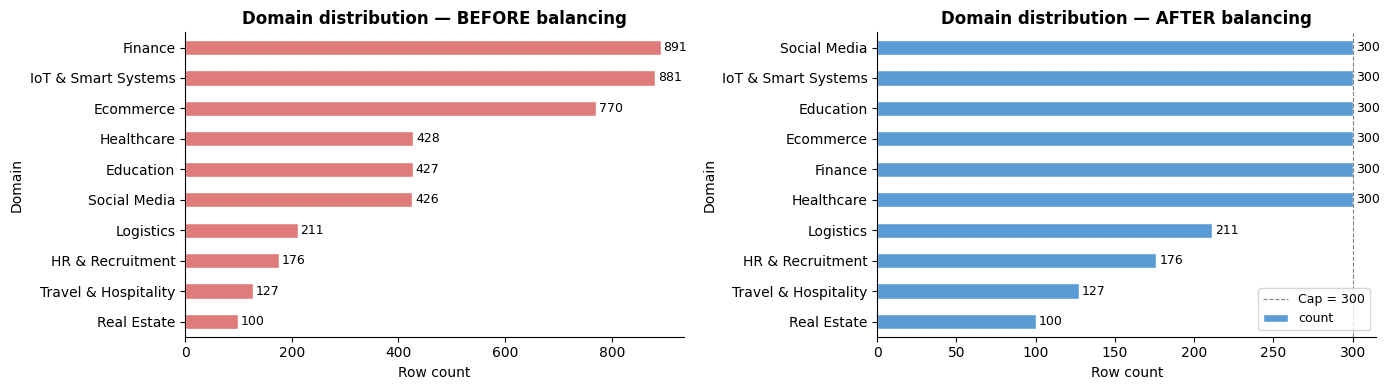

✓ Chart saved → domain_balance_before_after.png


In [5]:
# ══════════════════════════════════════════════════════════════
# CELL 5 ─ FIX B: Balance domain class imbalance
# ══════════════════════════════════════════════════════════════
# WHY: Finance has 891 rows but Real Estate only 100 — an 8.9x
# gap. A model trained on this will be heavily biased toward
# Finance and IoT, and will barely learn Real Estate or Travel.
#
# Strategy: Undersample — cap each domain at 300 rows.
# Domains already below 300 (Logistics: 211, HR: 176,
# Travel: 127, Real Estate: 100) keep ALL their rows.
# This is better than oversampling because our data is real
# GitHub repos — duplicating them would introduce data leakage.

CAP = 300
print(f"=== BEFORE balancing (cap = {CAP}) ===")
print(df["Domain"].value_counts().to_string())

frames = []
for domain, group in df.groupby("Domain"):
    frames.append(group.sample(min(len(group), CAP), random_state=42))

df = pd.concat(frames).reset_index(drop=True)

print(f"\n=== AFTER balancing ===")
print(df["Domain"].value_counts().to_string())
print(f"\nTotal rows after balancing : {len(df):,}")
print(f"  (removed {4437 - len(df):,} rows from over-represented domains)")

# ── Visualise domain balance ──────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

# Before
before_counts = df_raw["Domain"].value_counts().sort_values()
before_counts.plot(kind="barh", ax=axes[0], color="#E07B7B", edgecolor="white")
axes[0].set_title("Domain distribution — BEFORE balancing", fontweight="bold")
axes[0].set_xlabel("Row count")
for bar in axes[0].patches:
    axes[0].text(bar.get_width() + 5, bar.get_y() + bar.get_height()/2,
                 str(int(bar.get_width())), va="center", fontsize=9)
axes[0].spines[["top","right"]].set_visible(False)

# After
after_counts = df["Domain"].value_counts().sort_values()
after_counts.plot(kind="barh", ax=axes[1], color="#5B9BD5", edgecolor="white")
axes[1].set_title("Domain distribution — AFTER balancing", fontweight="bold")
axes[1].set_xlabel("Row count")
for bar in axes[1].patches:
    axes[1].text(bar.get_width() + 2, bar.get_y() + bar.get_height()/2,
                 str(int(bar.get_width())), va="center", fontsize=9)
axes[1].axvline(x=CAP, color="gray", linestyle="--", linewidth=0.8, label=f"Cap = {CAP}")
axes[1].legend(fontsize=9)
axes[1].spines[["top","right"]].set_visible(False)

plt.tight_layout()
plt.savefig("domain_balance_before_after.png", dpi=130, bbox_inches="tight")
plt.show()
print("✓ Chart saved → domain_balance_before_after.png")

In [6]:
# ══════════════════════════════════════════════════════════════
# CELL 6 ─ Ordinal encoding for ordered categorical columns
# ══════════════════════════════════════════════════════════════
# WHY: Project_Size, Budget_Level, Deployment have a natural
# order (Small < Medium < Large). Encoding them as 0/1/2
# preserves that ordering so the model can learn
# "larger projects tend to use X".
# One-hot encoding would lose the ordering relationship.

SIZE_MAP   = {"Small": 0, "Medium": 1, "Large": 2}
BUDGET_MAP = {"Low": 0,   "Medium": 1, "High": 2}
DEPLOY_MAP = {"On-premise": 0, "Cloud": 1}

df["Project_Size_enc"] = df["Project_Size"].map(SIZE_MAP)
df["Budget_Level_enc"] = df["Budget_Level"].map(BUDGET_MAP)
df["Deployment_enc"]   = df["Deployment"].map(DEPLOY_MAP)

print("✓ Ordinal encoding complete")
print("\nNull check after encoding (must be 0):")
print(df[["Project_Size_enc","Budget_Level_enc","Deployment_enc"]].isnull().sum().to_string())
print("\nSample encoding:")
print(df[["Project_Size","Project_Size_enc",
          "Budget_Level","Budget_Level_enc",
          "Deployment","Deployment_enc"]].drop_duplicates().head(6).to_string(index=False))

✓ Ordinal encoding complete

Null check after encoding (must be 0):
Project_Size_enc    0
Budget_Level_enc    0
Deployment_enc      0

Sample encoding:
Project_Size  Project_Size_enc Budget_Level  Budget_Level_enc Deployment  Deployment_enc
       Small                 0          Low                 0 On-premise               0
       Small                 0          Low                 0      Cloud               1
      Medium                 1       Medium                 1 On-premise               0
       Large                 2         High                 2      Cloud               1
       Large                 2         High                 2 On-premise               0
      Medium                 1       Medium                 1      Cloud               1


In [7]:
# ══════════════════════════════════════════════════════════════
# CELL 7 ─ One-hot encoding for Domain
# ══════════════════════════════════════════════════════════════
# WHY: Domain has NO natural order (Ecommerce is not "greater
# than" Healthcare), so we cannot use ordinal encoding.
# One-hot encoding creates 10 binary columns — one per domain.
# The model can then learn "this domain tends to use React".

domain_dummies = pd.get_dummies(df["Domain"], prefix="dom")

print(f"✓ One-hot encoding: {domain_dummies.shape[1]} domain columns created")
print("Columns:", list(domain_dummies.columns))
print("\nSample (first 3 rows):")
print(domain_dummies.head(3).to_string())

✓ One-hot encoding: 10 domain columns created
Columns: ['dom_Ecommerce', 'dom_Education', 'dom_Finance', 'dom_HR & Recruitment', 'dom_Healthcare', 'dom_IoT & Smart Systems', 'dom_Logistics', 'dom_Real Estate', 'dom_Social Media', 'dom_Travel & Hospitality']

Sample (first 3 rows):
   dom_Ecommerce  dom_Education  dom_Finance  dom_HR & Recruitment  dom_Healthcare  dom_IoT & Smart Systems  dom_Logistics  dom_Real Estate  dom_Social Media  dom_Travel & Hospitality
0           True          False        False                 False           False                    False          False            False             False                     False
1           True          False        False                 False           False                    False          False            False             False                     False
2           True          False        False                 False           False                    False          False            False             False         

In [8]:
# ══════════════════════════════════════════════════════════════
# CELL 8 ─ TF-IDF on Functional & Non-Functional Requirements
# ══════════════════════════════════════════════════════════════
# WHY: Your FR and NFR columns are text — the model cannot read
# strings. TF-IDF converts each word into a number that
# represents how important that word is across all rows.
# Example: "payment" appears often in Ecommerce rows but rarely
# in IoT rows → high TF-IDF weight for Ecommerce.
#
# Settings chosen for your dataset:
#   max_features=100 : keep the 100 most informative terms
#   ngram_range=(1,2): single words AND two-word phrases
#                      e.g. "real time" as one feature
#   stop_words="english": removes "the","is","and" etc.

df["combined_text"] = (
    df["Functional_Requirements"].fillna("") + " " +
    df["Non_Functional_Requirements"].fillna("")
)

tfidf = TfidfVectorizer(
    max_features  = 100,
    stop_words    = "english",
    ngram_range   = (1, 2),
    min_df        = 3,        # ignore terms appearing in fewer than 3 docs
    sublinear_tf  = True,     # apply log normalization to term frequencies
)

tfidf_matrix = tfidf.fit_transform(df["combined_text"])
tfidf_df     = pd.DataFrame(
    tfidf_matrix.toarray(),
    columns=[f"tfidf_{w}" for w in tfidf.get_feature_names_out()]
)

print(f"✓ TF-IDF matrix shape: {tfidf_df.shape}")
print(f"\nTop 20 most informative terms extracted:")
feature_names = tfidf.get_feature_names_out()
idf_scores    = tfidf.idf_
top_idx       = np.argsort(idf_scores)[:20]
for idx in top_idx:
    print(f"  {feature_names[idx]:<30} idf={idf_scores[idx]:.3f}")

# Save the vectorizer — you will need it later to process
# NEW project inputs in the prototype web app
joblib.dump(tfidf, "tfidf_vectorizer.pkl")
print("\n✓ TF-IDF vectorizer saved → tfidf_vectorizer.pkl")

✓ TF-IDF matrix shape: (2414, 100)

Top 20 most informative terms extracted:
  scalability                    idf=1.995
  performance                    idf=2.078
  compliance                     idf=2.260
  security                       idf=2.279
  availability                   idf=2.373
  high                           idf=2.403
  high availability              idf=2.408
  real                           idf=2.416
  time                           idf=2.462
  real time                      idf=2.470
  management                     idf=2.639
  reliability                    idf=2.778
  mobile                         idf=2.821
  responsiveness                 idf=2.847
  mobile responsiveness          idf=2.847
  data                           idf=2.871
  optimization                   idf=2.892
  audit                          idf=2.972
  low                            idf=3.027
  latency                        idf=3.037

✓ TF-IDF vectorizer saved → tfidf_vectorizer.pkl


In [9]:
# ══════════════════════════════════════════════════════════════
# CELL 9 ─ Label encode the 3 target columns
# ══════════════════════════════════════════════════════════════
# WHY: ML models output numbers, not strings.
# LabelEncoder maps each unique class to an integer:
#   Angular=0, Bootstrap=1, Flutter=2, ... React=6 etc.
# We save the encoders so we can decode predictions back to
# real technology names in the prototype later.

le_fe = LabelEncoder()
le_be = LabelEncoder()
le_db = LabelEncoder()

y_fe = le_fe.fit_transform(df["Frontend_Tech"])
y_be = le_be.fit_transform(df["Backend_Tech"])
y_db = le_db.fit_transform(df["Database"])

print("Frontend label mapping:")
for i, cls in enumerate(le_fe.classes_):
    count = (df["Frontend_Tech"] == cls).sum()
    print(f"  {i} → {cls:<15} ({count} samples)")

print("\nBackend label mapping:")
for i, cls in enumerate(le_be.classes_):
    count = (df["Backend_Tech"] == cls).sum()
    print(f"  {i} → {cls:<15} ({count} samples)")

print("\nDatabase label mapping:")
for i, cls in enumerate(le_db.classes_):
    count = (df["Database"] == cls).sum()
    print(f"  {i} → {cls:<15} ({count} samples)")

# Save encoders — essential for the prototype
joblib.dump(le_fe, "label_encoder_frontend.pkl")
joblib.dump(le_be, "label_encoder_backend.pkl")
joblib.dump(le_db, "label_encoder_database.pkl")
print("\n✓ Label encoders saved → label_encoder_*.pkl")


Frontend label mapping:
  0 → Angular         (234 samples)
  1 → Bootstrap       (96 samples)
  2 → Flutter         (64 samples)
  3 → HTML/CSS        (19 samples)
  4 → Next.js         (33 samples)
  5 → Other           (6 samples)
  6 → React           (1604 samples)
  7 → React Native    (162 samples)
  8 → Vue.js          (115 samples)
  9 → jQuery          (81 samples)

Backend label mapping:
  0 → ASP.NET         (92 samples)
  1 → Django          (535 samples)
  2 → Flask           (19 samples)
  3 → Flutter         (28 samples)
  4 → Go              (440 samples)
  5 → Laravel         (359 samples)
  6 → Node.js         (608 samples)
  7 → Other           (12 samples)
  8 → Rails           (118 samples)
  9 → Spring Boot     (203 samples)

Database label mapping:
  0 → Firebase        (62 samples)
  1 → MongoDB         (991 samples)
  2 → MySQL           (282 samples)
  3 → Other           (9 samples)
  4 → PostgreSQL      (957 samples)
  5 → Redis           (27 samples)
  6 →

In [10]:
# ══════════════════════════════════════════════════════════════
# CELL 10 ─ Build the final feature matrix X
# ══════════════════════════════════════════════════════════════
# Combine all encoded features into one matrix:
#
#   Numeric (5)      : Team_Size, Duration_Months,
#                      Project_Size_enc, Budget_Level_enc,
#                      Deployment_enc
#   Domain dummies   : 10 binary columns
#   TF-IDF features  : 100 text features
#   ─────────────────────────────────────────
#   TOTAL            : 115 features per row

numeric_feats = df[[
    "Team_Size",
    "Duration_Months",
    "Project_Size_enc",
    "Budget_Level_enc",
    "Deployment_enc",
]].reset_index(drop=True)

X = pd.concat([
    numeric_feats,
    domain_dummies.reset_index(drop=True),
    tfidf_df.reset_index(drop=True),
], axis=1)

# Sanity checks
assert X.isnull().sum().sum() == 0, "❌ NaN values found in X!"
assert len(X) == len(y_fe) == len(y_be) == len(y_db), "❌ Row count mismatch!"

print(f"✓ Final feature matrix X:")
print(f"  Shape            : {X.shape}  ({X.shape[0]} samples × {X.shape[1]} features)")
print(f"  Numeric features : 5  → {list(numeric_feats.columns)}")
print(f"  Domain dummies   : {domain_dummies.shape[1]}  → {list(domain_dummies.columns)}")
print(f"  TF-IDF features  : {tfidf_df.shape[1]}")
print(f"  NaN values       : {X.isnull().sum().sum()}  ✓")
print(f"\nTargets:")
print(f"  y_fe (Frontend)  : {len(np.unique(y_fe))} classes → {list(le_fe.classes_)}")
print(f"  y_be (Backend)   : {len(np.unique(y_be))} classes → {list(le_be.classes_)}")
print(f"  y_db (Database)  : {len(np.unique(y_db))} classes → {list(le_db.classes_)}")

# Save feature matrix
X.to_csv("X_features.csv", index=False)
print("\n✓ Feature matrix saved → X_features.csv")

✓ Final feature matrix X:
  Shape            : (2414, 115)  (2414 samples × 115 features)
  Numeric features : 5  → ['Team_Size', 'Duration_Months', 'Project_Size_enc', 'Budget_Level_enc', 'Deployment_enc']
  Domain dummies   : 10  → ['dom_Ecommerce', 'dom_Education', 'dom_Finance', 'dom_HR & Recruitment', 'dom_Healthcare', 'dom_IoT & Smart Systems', 'dom_Logistics', 'dom_Real Estate', 'dom_Social Media', 'dom_Travel & Hospitality']
  TF-IDF features  : 100
  NaN values       : 0  ✓

Targets:
  y_fe (Frontend)  : 10 classes → ['Angular', 'Bootstrap', 'Flutter', 'HTML/CSS', 'Next.js', 'Other', 'React', 'React Native', 'Vue.js', 'jQuery']
  y_be (Backend)   : 10 classes → ['ASP.NET', 'Django', 'Flask', 'Flutter', 'Go', 'Laravel', 'Node.js', 'Other', 'Rails', 'Spring Boot']
  y_db (Database)  : 8 classes → ['Firebase', 'MongoDB', 'MySQL', 'Other', 'PostgreSQL', 'Redis', 'SQL Server', 'SQLite']

✓ Feature matrix saved → X_features.csv


In [11]:
# ══════════════════════════════════════════════════════════════
# CELL 11 ─ Stratified 80/20 Train / Test split
# ══════════════════════════════════════════════════════════════
# WHY stratify=y_fe:
#   Without stratification, the random split might put ALL
#   HTML/CSS samples in train and NONE in test (or vice versa),
#   making evaluation impossible. Stratifying on y_fe ensures
#   every Frontend class appears proportionally in both sets.
#
# We stratify on Frontend because it has the most classes (10)
# and the smallest minority class (HTML/CSS: 28 samples).
# Backend and Database are larger so they split safely.

X_train, X_test, \
y_fe_train, y_fe_test, \
y_be_train, y_be_test, \
y_db_train, y_db_test = train_test_split(
    X, y_fe, y_be, y_db,
    test_size   = 0.2,
    random_state= 42,
    stratify    = y_fe
)

print("=== TRAIN / TEST SPLIT (80% / 20%) ===")
print(f"X_train : {X_train.shape}")
print(f"X_test  : {X_test.shape}")

print("\nFrontend class distribution — train vs test:")
print(f"{'Class':<16} {'Train':>6}  {'Test':>5}  {'Train%':>7}  {'Test%':>6}")
print("-" * 45)
for i, cls in enumerate(le_fe.classes_):
    tr = (y_fe_train == i).sum()
    te = (y_fe_test  == i).sum()
    tr_pct = tr / len(y_fe_train) * 100
    te_pct = te / len(y_fe_test)  * 100
    print(f"  {cls:<14} {tr:>6}  {te:>5}  {tr_pct:>6.1f}%  {te_pct:>5.1f}%")

print(f"\nBackend class distribution — train vs test:")
print(f"{'Class':<16} {'Train':>6}  {'Test':>5}")
print("-" * 32)
for i, cls in enumerate(le_be.classes_):
    tr = (y_be_train == i).sum()
    te = (y_be_test  == i).sum()
    print(f"  {cls:<14} {tr:>6}  {te:>5}")

print(f"\nDatabase class distribution — train vs test:")
print(f"{'Class':<16} {'Train':>6}  {'Test':>5}")
print("-" * 32)
for i, cls in enumerate(le_db.classes_):
    tr = (y_db_train == i).sum()
    te = (y_db_test  == i).sum()
    print(f"  {cls:<14} {tr:>6}  {te:>5}")

=== TRAIN / TEST SPLIT (80% / 20%) ===
X_train : (1931, 115)
X_test  : (483, 115)

Frontend class distribution — train vs test:
Class             Train   Test   Train%   Test%
---------------------------------------------
  Angular           187     47     9.7%    9.7%
  Bootstrap          77     19     4.0%    3.9%
  Flutter            51     13     2.6%    2.7%
  HTML/CSS           15      4     0.8%    0.8%
  Next.js            26      7     1.3%    1.4%
  Other               5      1     0.3%    0.2%
  React            1283    321    66.4%   66.5%
  React Native      130     32     6.7%    6.6%
  Vue.js             92     23     4.8%    4.8%
  jQuery             65     16     3.4%    3.3%

Backend class distribution — train vs test:
Class             Train   Test
--------------------------------
  ASP.NET            69     23
  Django            415    120
  Flask              15      4
  Flutter            22      6
  Go                344     96
  Laravel           299     60
  N

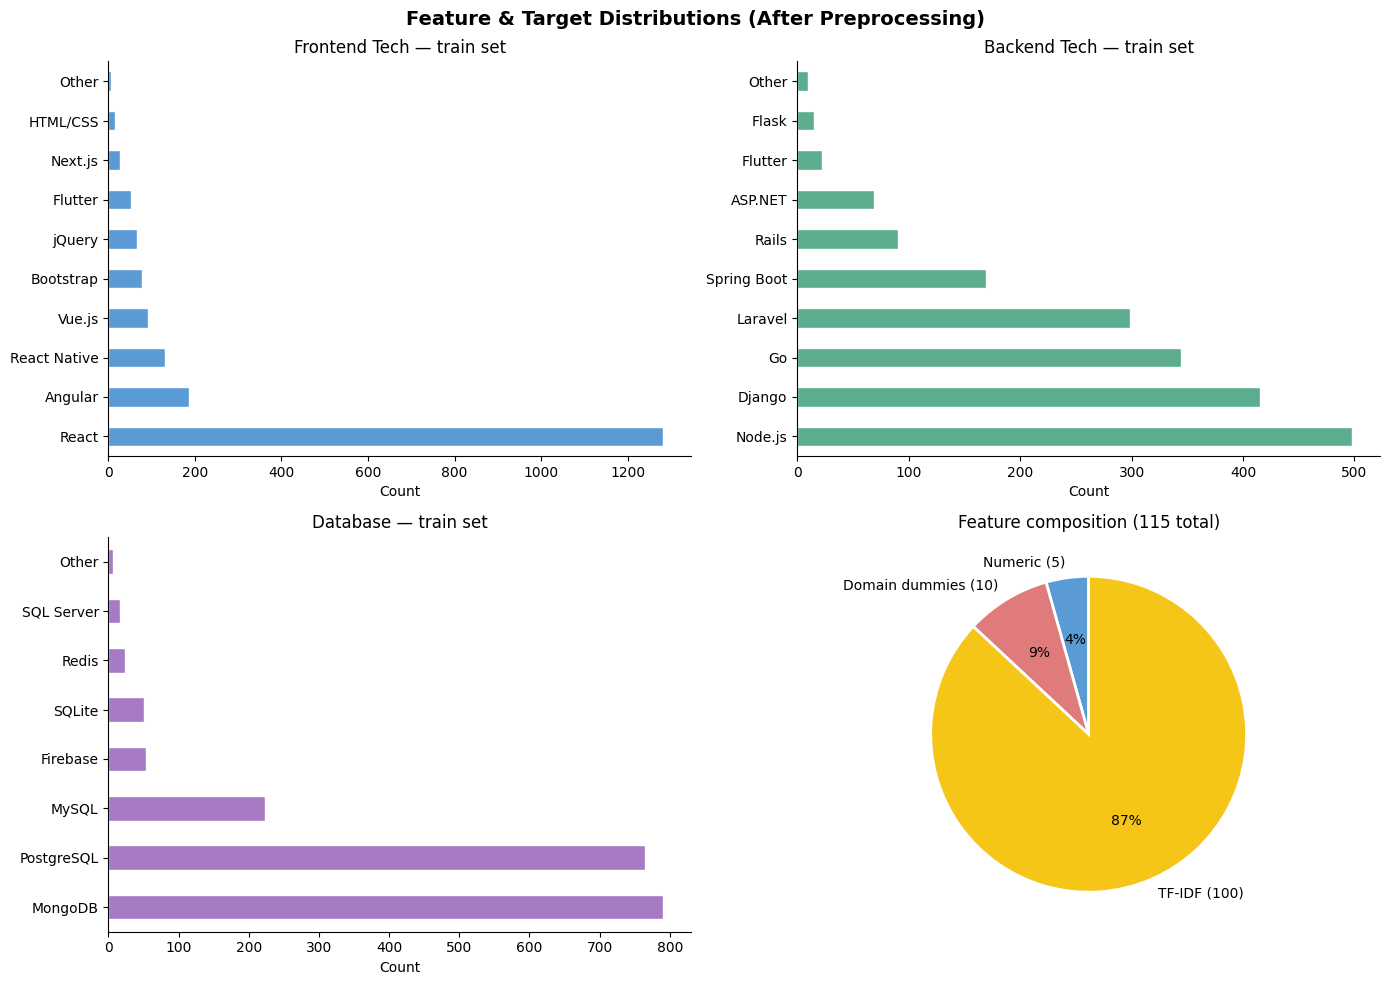

✓ Distribution chart saved → preprocessing_distributions.png


In [12]:
# ══════════════════════════════════════════════════════════════
# CELL 12 ─ Visualise feature distribution (for thesis)
# ══════════════════════════════════════════════════════════════
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
fig.suptitle("Feature & Target Distributions (After Preprocessing)",
             fontsize=14, fontweight="bold")

# Frontend distribution
fe_counts = pd.Series(y_fe_train).map(dict(enumerate(le_fe.classes_))).value_counts()
fe_counts.plot(kind="barh", ax=axes[0,0], color="#5B9BD5", edgecolor="white")
axes[0,0].set_title("Frontend Tech — train set")
axes[0,0].set_xlabel("Count")
axes[0,0].spines[["top","right"]].set_visible(False)

# Backend distribution
be_counts = pd.Series(y_be_train).map(dict(enumerate(le_be.classes_))).value_counts()
be_counts.plot(kind="barh", ax=axes[0,1], color="#5BAD8E", edgecolor="white")
axes[0,1].set_title("Backend Tech — train set")
axes[0,1].set_xlabel("Count")
axes[0,1].spines[["top","right"]].set_visible(False)

# Database distribution
db_counts = pd.Series(y_db_train).map(dict(enumerate(le_db.classes_))).value_counts()
db_counts.plot(kind="barh", ax=axes[1,0], color="#A67BC4", edgecolor="white")
axes[1,0].set_title("Database — train set")
axes[1,0].set_xlabel("Count")
axes[1,0].spines[["top","right"]].set_visible(False)

# Feature groups pie chart
feature_groups = {
    "Numeric (5)":       5,
    "Domain dummies (10)": 10,
    "TF-IDF (100)":     100,
}
axes[1,1].pie(
    list(feature_groups.values()),
    labels=list(feature_groups.keys()),
    colors=["#5B9BD5","#E07B7B","#F5C518"],
    autopct="%1.0f%%", startangle=90,
    wedgeprops={"edgecolor":"white","linewidth":2}
)
axes[1,1].set_title(f"Feature composition (115 total)")

plt.tight_layout()
plt.savefig("preprocessing_distributions.png", dpi=130, bbox_inches="tight")
plt.show()
print("✓ Distribution chart saved → preprocessing_distributions.png")

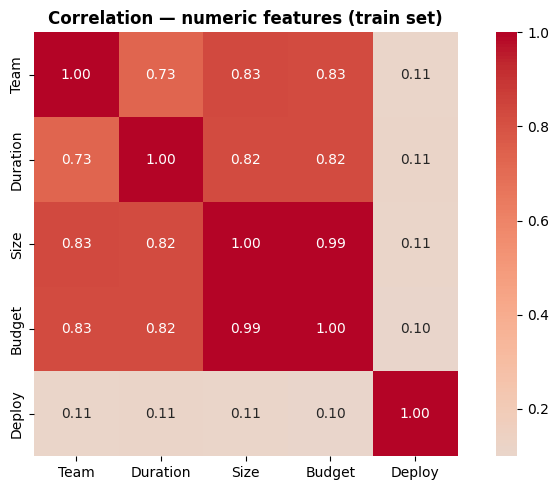

✓ Correlation chart saved → numeric_correlation.png


In [13]:
# ══════════════════════════════════════════════════════════════
# CELL 13 ─ Correlation heatmap of numeric features
# ══════════════════════════════════════════════════════════════
fig, ax = plt.subplots(figsize=(8, 5))
num_cols = ["Team_Size","Duration_Months","Project_Size_enc","Budget_Level_enc","Deployment_enc"]
corr = X_train[num_cols].corr()
sns.heatmap(corr, annot=True, fmt=".2f", cmap="coolwarm",
            center=0, ax=ax, square=True,
            xticklabels=["Team","Duration","Size","Budget","Deploy"],
            yticklabels=["Team","Duration","Size","Budget","Deploy"])
ax.set_title("Correlation — numeric features (train set)", fontweight="bold")
plt.tight_layout()
plt.savefig("numeric_correlation.png", dpi=130, bbox_inches="tight")
plt.show()
print("✓ Correlation chart saved → numeric_correlation.png")

In [14]:
# ══════════════════════════════════════════════════════════════
# CELL 14 ─ Save all outputs
# ══════════════════════════════════════════════════════════════
# Save train/test splits — this is the main file for Cell 15
# and for model training in Phase 4
joblib.dump({
    "X_train":     X_train,
    "X_test":      X_test,
    "y_fe_train":  y_fe_train,
    "y_fe_test":   y_fe_test,
    "y_be_train":  y_be_train,
    "y_be_test":   y_be_test,
    "y_db_train":  y_db_train,
    "y_db_test":   y_db_test,
    "le_fe":       le_fe,
    "le_be":       le_be,
    "le_db":       le_db,
    "feature_names": list(X.columns),
}, "train_test_splits.pkl")

print("=" * 58)
print("  PREPROCESSING COMPLETE — SUMMARY")
print("=" * 58)
print(f"  Original rows         : 4,437")
print(f"  After rare grouping   : 4,437  (classes merged, no rows lost)")
print(f"  After domain balance  : {len(df):,}")
print(f"  Feature columns (X)   : {X.shape[1]}  (5 numeric + 10 domain + 100 TF-IDF)")
print(f"  Train samples         : {X_train.shape[0]}")
print(f"  Test  samples         : {X_test.shape[0]}")
print(f"  Frontend classes      : {len(le_fe.classes_)} → {list(le_fe.classes_)}")
print(f"  Backend  classes      : {len(le_be.classes_)} → {list(le_be.classes_)}")
print(f"  Database classes      : {len(le_db.classes_)} → {list(le_db.classes_)}")
print("=" * 58)
print("\nFiles saved:")
print("  train_test_splits.pkl       ← MAIN file for Phase 4 model training")
print("  tfidf_vectorizer.pkl        ← for processing new user inputs")
print("  label_encoder_frontend.pkl  ← decoding predictions → tech names")
print("  label_encoder_backend.pkl")
print("  label_encoder_database.pkl")
print("  X_features.csv              ← optional: inspect features in Excel")
print("  domain_balance_before_after.png")
print("  preprocessing_distributions.png")
print("  numeric_correlation.png")

  PREPROCESSING COMPLETE — SUMMARY
  Original rows         : 4,437
  After rare grouping   : 4,437  (classes merged, no rows lost)
  After domain balance  : 2,414
  Feature columns (X)   : 115  (5 numeric + 10 domain + 100 TF-IDF)
  Train samples         : 1931
  Test  samples         : 483
  Frontend classes      : 10 → ['Angular', 'Bootstrap', 'Flutter', 'HTML/CSS', 'Next.js', 'Other', 'React', 'React Native', 'Vue.js', 'jQuery']
  Backend  classes      : 10 → ['ASP.NET', 'Django', 'Flask', 'Flutter', 'Go', 'Laravel', 'Node.js', 'Other', 'Rails', 'Spring Boot']
  Database classes      : 8 → ['Firebase', 'MongoDB', 'MySQL', 'Other', 'PostgreSQL', 'Redis', 'SQL Server', 'SQLite']

Files saved:
  train_test_splits.pkl       ← MAIN file for Phase 4 model training
  tfidf_vectorizer.pkl        ← for processing new user inputs
  label_encoder_frontend.pkl  ← decoding predictions → tech names
  label_encoder_backend.pkl
  label_encoder_database.pkl
  X_features.csv              ← optional: 

In [15]:
# ══════════════════════════════════════════════════════════════
# CELL 15 ─ Quick sanity check — load and verify saved files
# ══════════════════════════════════════════════════════════════
print("Loading saved files to verify...")
saved = joblib.load("train_test_splits.pkl")

assert saved["X_train"].shape == X_train.shape
assert saved["X_test"].shape  == X_test.shape
assert list(saved["le_fe"].classes_) == list(le_fe.classes_)

print("✓ train_test_splits.pkl  — verified")
print(f"  X_train: {saved['X_train'].shape}  X_test: {saved['X_test'].shape}")

tfidf_loaded = joblib.load("tfidf_vectorizer.pkl")
print(f"✓ tfidf_vectorizer.pkl   — {len(tfidf_loaded.vocabulary_)} terms")

le_loaded = joblib.load("label_encoder_frontend.pkl")
print(f"✓ label_encoder_frontend — {len(le_loaded.classes_)} classes: {list(le_loaded.classes_)}")

print("\n✓ All files verified. Ready for Phase 4 — Model Training.")
print("  Next step: say 'Guide me through model training'")

Loading saved files to verify...
✓ train_test_splits.pkl  — verified
  X_train: (1931, 115)  X_test: (483, 115)
✓ tfidf_vectorizer.pkl   — 100 terms
✓ label_encoder_frontend — 10 classes: ['Angular', 'Bootstrap', 'Flutter', 'HTML/CSS', 'Next.js', 'Other', 'React', 'React Native', 'Vue.js', 'jQuery']

✓ All files verified. Ready for Phase 4 — Model Training.
  Next step: say 'Guide me through model training'


In [16]:
# ══════════════════════════════════════════════════════════════
# CELL 16 ─ Download all output files from Colab
# ══════════════════════════════════════════════════════════════
OUTPUT_FILES = [
    "train_test_splits.pkl",
    "tfidf_vectorizer.pkl",
    "label_encoder_frontend.pkl",
    "label_encoder_backend.pkl",
    "label_encoder_database.pkl",
    "X_features.csv",
    "domain_balance_before_after.png",
    "preprocessing_distributions.png",
    "numeric_correlation.png",
]

for f in OUTPUT_FILES:
    if os.path.exists(f):
        files.download(f)
        print(f"  ⬇ Downloading {f}")
    else:
        print(f"  ⚠ Not found: {f}")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

  ⬇ Downloading train_test_splits.pkl


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

...

<IPython.core.display.Javascript object>

  ⬇ Downloading preprocessing_distributions.png


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

  ⬇ Downloading numeric_correlation.png
